--- brand_id별 데이터 개수 ---
   brand_id  count
0         2    420
1         1    152
2         3    109


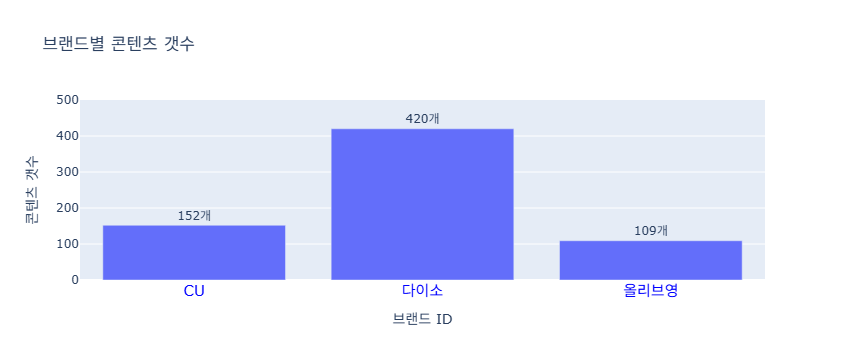

In [18]:
#콘텐츠 개수비교 시각화

import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px




# 2. CSV 파일 불러오기
file_path = r"C:\Users\HJkim\data_teamproject_a\ampm_2U\02_MergeData\merged_brand_content_with_id_f.csv"
df = pd.read_csv(file_path, encoding="utf-8-sig")

# 2. brand_id별 데이터 개수 도출하기
brand_counts_df = df['brand_id'].value_counts().reset_index()

print("--- brand_id별 데이터 개수 ---")
print(brand_counts_df)

# 3. Plotly로 막대그래프 그리기
# 요약된 표(brand_counts_df)를 통째로 넘겨주고 컬럼명만 쏙쏙 지정합니다.
fig = px.bar(
    brand_counts_df, 
    x='brand_id',    # x축: 브랜드 ID (데이터 종류 3개)
    y='count',       # y축: 데이터 갯수 (요약 값 3개) -> 길이기 3으로 완벽히 일치!
    text='count',
    title="브랜드별 콘텐츠 갯수",
    labels={"brand_id": "브랜드 ID", "count": "콘텐츠 갯수"}
)

# 4. 레이아웃 디자인 수정 (Blue 뒤에 따옴표 '' 누락되었던 부분도 수정했습니다!)
fig.update_traces(
    textposition='outside', # 숫자를 막대 바깥쪽(위)에 표시 ('inside'로 하면 막대 안으로 들어갑니다)
    texttemplate='%{text}개' # 숫자 뒤에 '개'라는 단어를 붙여서 출력
)

# 5. 레이아웃 디자인 수정
fig.update_layout(
    xaxis={
        "tickfont": {
            "size": 15,
            "color": "Blue"
        },
        "tickvals": [1, 2, 3],                   # 💡 원래 데이터에 있던 x축 값들
        "ticktext": ["CU", "다이소", "올리브영"]  # 💡 화면에 대신 보여줄 브랜드 이름들!
    },
    yaxis={
        "range": [0, 500] # 💡 [핵심] y축의 시작값(0)과 최댓값(500)을 직접 지정!
    }
)

fig.show()

In [19]:
!pip install konlpy

   ---------------------------------------- 0.0/19.4 MB ? eta -:--:--
   ------------------------ --------------- 12.1/19.4 MB 59.7 MB/s eta 0:00:01
   ---------------------------------------  19.4/19.4 MB 61.3 MB/s eta 0:00:01
   ---------------------------------------- 19.4/19.4 MB 45.3 MB/s  0:00:00

   ---------------------------------------- 0/2 [JPype1]
   ---------------------------------------- 0/2 [JPype1]
   ---------------------------------------- 0/2 [JPype1]
   ---------------------------------------- 0/2 [JPype1]
   ---------------------------------------- 0/2 [JPype1]
   ---------------------------------------- 0/2 [JPype1]
   ---------------------------------------- 0/2 [JPype1]
   -------------------- ------------------- 1/2 [konlpy]
   -------------------- ------------------- 1/2 [konlpy]
   -------------------- ------------------- 1/2 [konlpy]
   -------------------- ------------------- 1/2 [konlpy]
   -------------------- ------------------- 1/2 [konlpy]
   --------

In [21]:
!pip install kiwipiepy

     ---------------------------------------- 0.0/88.0 MB ? eta -:--:--
     ----- --------------------------------- 11.8/88.0 MB 60.6 MB/s eta 0:00:02
     --------- ----------------------------- 21.2/88.0 MB 52.0 MB/s eta 0:00:02
     --------- ----------------------------- 21.5/88.0 MB 39.1 MB/s eta 0:00:02
     -------------- ------------------------ 31.7/88.0 MB 36.2 MB/s eta 0:00:02
     --------------- ----------------------- 34.1/88.0 MB 32.6 MB/s eta 0:00:02
     ------------------- ------------------- 43.0/88.0 MB 33.3 MB/s eta 0:00:02
     ------------------------ -------------- 54.8/88.0 MB 36.4 MB/s eta 0:00:01
     ---------------------------- ---------- 63.7/88.0 MB 37.0 MB/s eta 0:00:01
     ---------------------------- ---------- 64.2/88.0 MB 34.3 MB/s eta 0:00:01
     ------------------------------ -------- 69.5/88.0 MB 32.1 MB/s eta 0:00:01
     ---------------------------------- ---- 76.8/88.0 MB 32.8 MB/s eta 0:00:01
     ----------------------------------- --- 79.

In [25]:
#형태소 분석

import pandas as pd
from kiwipiepy import Kiwi
from collections import Counter

# 1. 데이터 로드
file_path = r"C:\Users\HJkim\data_teamproject_a\ampm_2U\02_MergeData\merged_brand_content_with_id_f.csv"
df = pd.read_csv(file_path, encoding="utf-8-sig")

# 2. 텍스트 병합
df['full_text'] = df['title'].fillna('') + " " + df['caption_text'].fillna('')
all_text = " ".join(df['full_text'])

# 3. 자바가 필요 없는 Kiwi 형태소 분석기 생성 ✨
kiwi = Kiwi()

print("명사, 동사, 형용사 추출 중... 잠시만 기다려주세요.")
# 4. 형태소 분석 진행
tokens = kiwi.tokenize(all_text)

# 5. 불용어 리스트
stopwords = ['것', '이', '수', '거', '개', '존', '및', '위', '등', '더', '를', '회', '바로', '요즘', '링크', ]

# 6. 품사 필터링 (NNG/NNP: 명사, VV: 동사, VA: 형용사)
combined_words = []
for token in tokens:
    if token.tag in ['NNG', 'NNP', 'VV', 'VA']:
        word = token.form
        if word not in stopwords and len(word) > 1:
            # 품사 한글명 매핑 및 동사/형용사 기본형 화('다' 붙이기)
            if token.tag in ['NNG', 'NNP']:
                pos_kor = '명사'
            elif token.tag == 'VV':
                pos_kor = '동사'
                word += '다'
            elif token.tag == 'VA':
                pos_kor = '형용사'
                word += '다'
                
            combined_words.append(f"{word}({pos_kor})")

# 7. 빈도수 카운트 및 Top 30 도출
word_counts = Counter(combined_words)
top_words = word_counts.most_common(50)

print("\n--- 가장 빈번하게 언급된 단어 Top 30 (Kiwi 분석기 결과) ---")
for word, count in top_words:
    print(f"{word}: {count}회")

명사, 동사, 형용사 추출 중... 잠시만 기다려주세요.

--- 가장 빈번하게 언급된 단어 Top 30 (Kiwi 분석기 결과) ---
가격(명사): 1066회
다이소(명사): 881회
건강(명사): 808회
영양제(명사): 715회
비타민(명사): 391회
제품(명사): 299회
식품(명사): 297회
건기식(명사): 278회
추천(명사): 271회
기능(명사): 254회
대웅제약(명사): 230회
쿠팡(명사): 227회
제공(명사): 199회
건조(명사): 192회
종근당(명사): 191회
영상(명사): 190회
할인(명사): 183회
구매(명사): 178회
오메가(명사): 172회
국민(명사): 167회
혜택(명사): 163회
유산균(명사): 154회
챙기다(동사): 153회
위하다(동사): 151회
성분(명사): 145회
만나다(동사): 143회
프로젝트(명사): 140회
따르다(동사): 136회
콜라겐(명사): 136회
상품(명사): 134회
올리브(명사): 129회
프리미엄(명사): 125회
마그네슘(명사): 121회
가성비(명사): 118회
활동(명사): 116회
건조기(명사): 115회
품질(명사): 112회
수수료(명사): 111회
감사(명사): 109회
팔리다(동사): 109회
포스팅(명사): 106회
파트너스(명사): 105회
확인(명사): 104회
일환(명사): 103회
일정액(명사): 102회
필수(명사): 101회
판매(명사): 99회
약사(명사): 99회
필요(명사): 97회
다이어트(명사): 96회


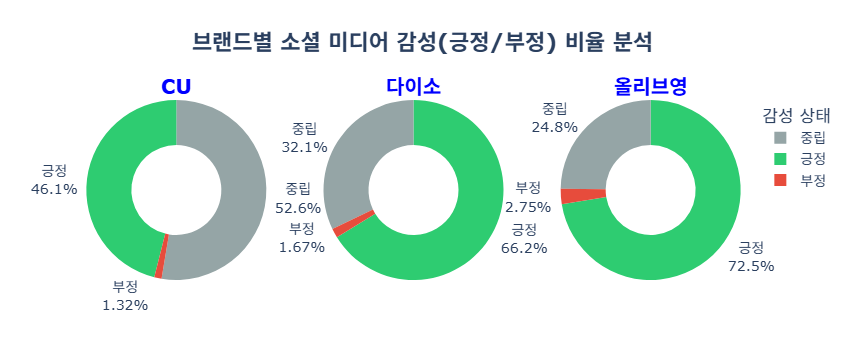

In [41]:
#브랜드별 긍부정도 분석 _ comment도 합쳐봐도 좋을 것 같습니다.

import pandas as pd
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# 1. 데이터 불러오기 및 전처리
file_path = r"C:\Users\HJkim\data_teamproject_a\ampm_2U\02_MergeData\merged_brand_content_with_id_f.csv"
df = pd.read_csv(file_path, encoding="utf-8-sig")

# 텍스트 합치기 및 결측치 처리
df['full_text'] = df['title'].fillna('') + " " + df['caption_text'].fillna('') + " " + df['hashtags'].fillna('')

# 2. 감성 사전 정의 및 분석
positive_words = ['할인', '꿀템', '대박', '추천', '신뢰','믿을만', '싸다', '가성비', '이벤트', '오픈', '인기', '좋다', '득템','난리난', '대란', '저렴', '만족','추천','재구매', '유용']
negative_words = ['비싸다', '별로', '부작용', '실망', '아쉽', '정가', '부담', '조심', '단점', '과장', '거부',  '부족', '아깝다','후회']

def analyze_sentiment(text):
    text = str(text)
    pos_score = sum(1 for word in positive_words if word in text)
    neg_score = sum(1 for word in negative_words if word in text)
    if pos_score > neg_score: return '긍정'
    elif neg_score > pos_score: return '부정'
    else: return '중립'

df['sentiment'] = df['full_text'].apply(analyze_sentiment)

# brand_id 맵핑 (1:CU, 2:다이소, 3:올리브영)
brand_map = {1: 'CU', 2: '다이소', 3: '올리브영'}
df['brand_name'] = df['brand_id'].map(brand_map)

# 3. 3개의 도넛 차트를 가로로 나란히 배치하기 위한 서브플롯 생성
# specs 변수에 각각 'domain'(파이형/도넛형 차트 구역) 타입을 지정해 줍니다.
fig = make_subplots(
    rows=1, cols=3, 
    specs=[[{'type': 'domain'}, {'type': 'domain'}, {'type': 'domain'}]],
    subplot_titles=['CU', '다이소', '올리브영'] # 각 차트 위에 보일 브랜드 제목
)

# 색상 매핑 지정을 위한 딕셔너리
color_map = {'긍정': '#2ecc71', '중립': '#95a5a6', '부정': '#e74c3c'}

# 4. 각 브랜드별로 데이터를 필터링하여 도넛 차트(Pie trace) 조각 추가
brands = ['CU', '다이소', '올리브영']

for i, brand in enumerate(brands, 1):
    # 해당 브랜드 데이터만 필터링
    brand_df = df[df['brand_name'] == brand]
    # 감성별 개수 카운트
    sentiment_counts = brand_df['sentiment'].value_counts().reset_index()
    
    # 해당 브랜드에 매핑할 색상 순서 맞추기
    colors = [color_map[sent] for sent in sentiment_counts['sentiment']]
    
    # 도넛 차트 객체 생성 및 서브플롯에 추가
    fig.add_trace(
        go.Pie(
            labels=sentiment_counts['sentiment'],
            values=sentiment_counts['count'],
            name=brand,
            hole=0.5, 
            marker=dict(colors=colors),
            textinfo='label+percent', 
            hoverinfo='label+value+percent',
            textposition='outside',
            
            # 💡 [핵심] 텍스트가 회전하지 않고 무조건 가로(수평)로 나오게 고정합니다!
            insidetextorientation='horizontal' 
        ),
        row=1, col=i
    )

# 5. 레이아웃 및 타이틀 다듬기
fig.update_layout(
    title_text="브랜드별 소셜 미디어 감성(긍정/부정) 비율 분석",
    title_font=dict(size=22, weight='bold'), # 전체 메인 타이틀 크기 및 굵기
    title_x=0.5, # 타이틀 가운데 정렬
    legend_title_text="감성 상태",
    font=dict(size=14) # 기본 텍스트 크기
)

# 💡 [핵심] 각 도넛 차트 상단에 있는 브랜드 이름(CU, 다이소, 올리브영) 스타일 일괄 수정
fig.for_each_annotation(lambda a: a.update(
    font=dict(
        size=20,          # 👈 글자 크기를 20으로 키우고
        weight='bold',    # 👈 글씨를 두껍게(Bold) 설정!
        color='bLue'     # 👈 색상을 선명하게 검은색으로 지정
    )
))
# 6. 그래프 출력
fig.show()